# Feature Engineering and Ensemble Learning

**Chapter Introduction**

This notebook accompanies the *Feature Engineering* lecture. It walks through:

1. **Overview of feature engineering** — what it is and why it matters
2. **Transforming numerical variables** — scaling and log transformation
3. **Transforming categorical variables** — label encoding, one-hot encoding, and cross features
4. **Use of domain knowledge** — turning raw data into meaningful features
5. **Ensembling** — bagging, boosting, and the bias-variance tradeoff

A separate session covers model evaluation metrics (MSE, R², precision/recall/F1, ROC-AUC, ...), so those are intentionally not duplicated here.


In [1]:
# Standard libraries
import numpy as np
import numpy.random as random
import pandas as pd
from pandas import Series, DataFrame
import warnings

# Display up to three decimal places
%precision 3

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

# Ignore warnings
warnings.filterwarnings('ignore')

# scikit-learn building blocks used in multiple sections
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import r2_score, accuracy_score


In [2]:
# Regression task: California Housing
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame=True)
X_housing = california_housing.data
y_housing = california_housing.target

# Classification task: Breast Cancer
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
X_cancer = cancer.data
y_cancer = cancer.target

print('California Housing:', X_housing.shape, '/ target:', y_housing.shape)
print('Breast Cancer    :', X_cancer.shape,  '/ target:', y_cancer.shape)


California Housing: (20640, 8) / target: (20640,)
Breast Cancer    : (569, 30) / target: (569,)


In [3]:
X_housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
X_housing.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [5]:
y_housing.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [6]:
# Import from scikit-learn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Extract target variables
x = df[['sepal length (cm)']]

# Create and apply StandardScaler
ss = StandardScaler()
x_std = ss.fit_transform(x)

# Compare pre- and post-transformation values
x['sepal length std'] = x_std
display(x)

# Compare pre- and post-transformation (mean and standard deviation)
x.describe().loc[['mean', 'std'], :]

,sepal length (cm),sepal length std
0,5.1,-0.900681
1,4.9,-1.143017
2,4.7,-1.385353
3,4.6,-1.506521
4,5.0,-1.021849
...,...,...
145,6.7,1.038005
146,6.3,0.553333
147,6.5,0.795669
148,6.2,0.432165


,sepal length (cm),sepal length std
mean,5.843333,-4.736952e-16
std,0.828066,1.003350e+00


In [7]:
# Import from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Preparing data
X = df[['sepal length (cm)']]
y = df.loc[:, "target"]

# Split into training and test datasets
X_train, X_valid, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Prepare models
mods = {
    'LogisticRegression': LogisticRegression(C=0.01, random_state=42),
    'StandardScaler + LogisticRegression': Pipeline([('ss', StandardScaler()), ('model', LogisticRegression(C=0.01, random_state=42))]),
    'DecisonTree': DecisionTreeClassifier(random_state=42),
    'StandardScaler + DecisonTree': Pipeline([('ss', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))])
}

# Model training and evaluation
results = {}
for mod_name, mod in mods.items():
    mod.fit(X_train, y_train)
    results[(mod_name, 'train')] = round(accuracy_score(y_train, mod.predict(X_train)), 3)
    results[(mod_name, 'valid')] = round(accuracy_score(y_test, mod.predict(X_valid)), 3)

# Organizing the results
pd.Series(results).unstack().iloc[[1, 3, 0, 2]]

,train,valid
LogisticRegression,0.610,0.533
StandardScaler + LogisticRegression,0.705,0.600
DecisonTree,0.771,0.756
StandardScaler + DecisonTree,0.771,0.756


Two things to notice:

- **Logistic regression is sensitive to scale** — performance changes meaningfully when a `StandardScaler` is added in front of it.
- **The decision tree is essentially scale-invariant** — its score barely moves whether the input is standardized or not. We will see *why* in section 2.3.


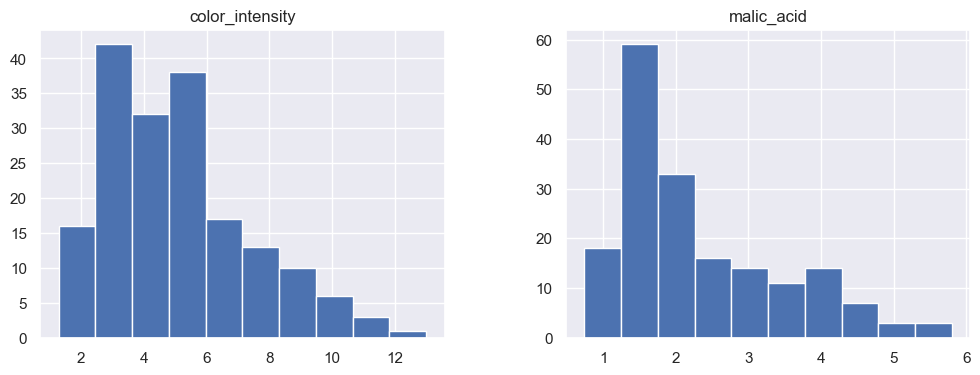

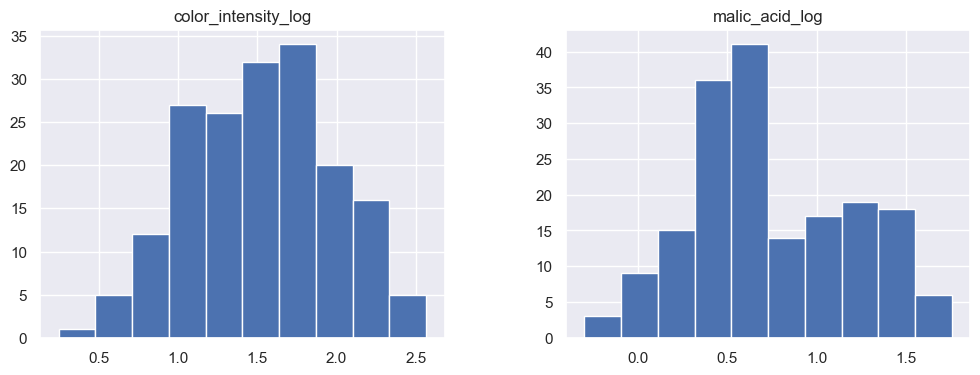

In [8]:
# Import from scikit-learn
from sklearn.datasets import load_wine

# Load data
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['variety'] = wine.target

# Extract target variables
cols = ['color_intensity', 'malic_acid']
X = df[cols]

# Display original distributions
X.hist(figsize=(12, 4))

# Apply logarithmic transformation
X_log = np.log(X)
cols_log = [s + '_log' for s in cols]
X_log.columns = cols_log

# Display transformed distributions
X_log.hist(figsize=(12, 4))
plt.show()

The skewness in both histograms is much reduced after the log transformation.

Does it actually help downstream classification? Compare the performance of logistic regression using these variables as explanatory variables.

- Explanatory Variables: `color_intensity`, `malic_acid`
- Target Variable: `variety` (wine type, 3 classes)
- Model: Logistic Regression
- Variable Transformation: With and without logarithmic transformation
- Evaluation Metric: F1 Score
- Validation Method: 5-fold Cross-Validation

In [9]:
# Import from scikit-learn
from sklearn.model_selection import cross_val_score

# Define target variable
target_variable = df['variety']

# Create model
logistic_model = LogisticRegression(random_state=42)

# Train and evaluate model using cross-validation
# Without logarithmic transformation
cv_score_without_log_transform = cross_val_score(logistic_model, X, target_variable, cv=5, scoring='f1_weighted').mean()

# With logarithmic transformation
cv_score_with_log_transform = cross_val_score(logistic_model, X_log, target_variable, cv=5, scoring='f1_weighted').mean()

# Display results
print('Cross-validation score (w/o log transformation): {:.3f}'.format(cv_score_without_log_transform))
print('Cross-validation score (w/ log transformation): {:.3f}'.format(cv_score_with_log_transform))

Cross-validation score (w/o log transformation): 0.768
Cross-validation score (w/ log transformation): 0.797
